In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
BLUE = "#0072B2"

boxoffice = pd.DataFrame({
    "title": ["Star Wars", "Jumanji", "Pitch Perfect 3", "Greatest Showman", "Ferdinand"],
    "amount": [71.57, 36.17, 19.93, 8.81, 7.32],
}).sort_values("amount")

temps = pd.read_csv("tempnormals.csv")
houston = temps.loc[temps["location"] == "Houston"].sort_values("day_of_year")
san_diego = temps.loc[temps["location"] == "San Diego"].sort_values("day_of_year")
death_valley = temps.loc[temps["location"] == "Death Valley"].sort_values("day_of_year")
chicago = temps.loc[temps["location"] == "Chicago"].sort_values("day_of_year")

def fahrenheit_to_celsius(temp_f):
    return (temp_f - 32) * 5 / 9

houston_angle = (houston["day_of_year"] - 1) / 365 * 2 * np.pi
death_valley_angle = (death_valley["day_of_year"] - 1) / 365 * 2 * np.pi
san_diego_angle = (san_diego["day_of_year"] - 1) / 365 * 2 * np.pi
chicago_angle = (chicago["day_of_year"] - 1) / 365 * 2 * np.pi

census = pd.read_csv("US_census.csv")
texas = census.loc[census["state"] == "Texas"].copy()
texas["county"] = texas["name"].str.replace(" County", "", regex=False)
median_pop = texas["pop2010"].median()
texas["popratio"] = texas["pop2010"] / median_pop
texas = texas.sort_values("popratio", ascending=False).reset_index(drop=True)
texas["index"] = texas.index + 1

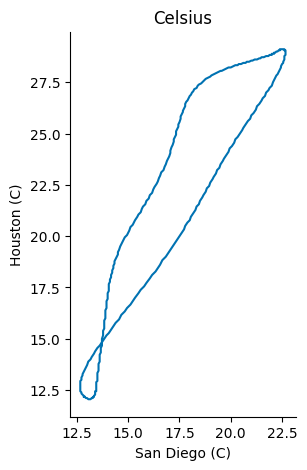

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))

sd_celsius = fahrenheit_to_celsius(san_diego["temperature"])
houston_celsius = fahrenheit_to_celsius(houston["temperature"])

ax.plot(sd_celsius, houston_celsius, color=BLUE)
ax.set_aspect("equal")

ax.set_xlabel("San Diego (C)")
ax.set_ylabel("Houston (C)")
ax.set_title("Celsius")

plt.show()

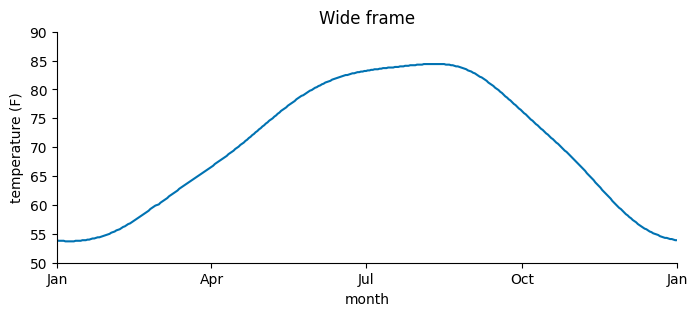

In [11]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(houston["day_of_year"], houston["temperature"], color=BLUE)

ax.set_ylim(50, 90)
ax.set_ylabel("temperature (F)")

ax.set_xlim(1, 366)
ax.set_xticks([1, 92, 183, 275, 366])
ax.set_xticklabels(["Jan", "Apr", "Jul", "Oct", "Jan"])
ax.set_xlabel("month")
ax.set_title("Wide frame")

plt.show()

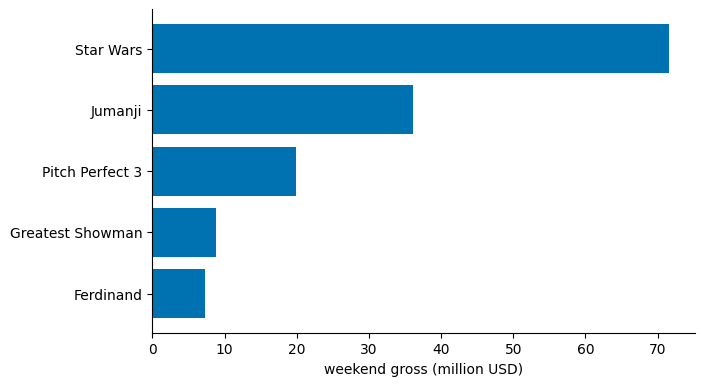

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(boxoffice["title"], boxoffice["amount"], color=BLUE)
ax.set_xlabel("weekend gross (million USD)")
ax.set_ylabel("")
plt.show()

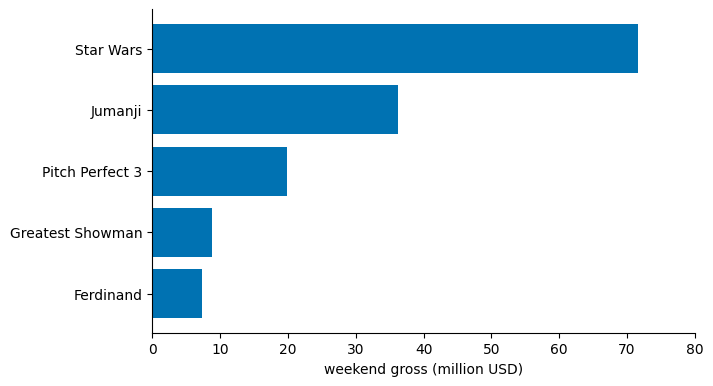

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(boxoffice["title"], boxoffice["amount"], color=BLUE)
ax.set_xlim(0, 80)
ax.set_xlabel("weekend gross (million USD)")
ax.set_ylabel("")
plt.show()

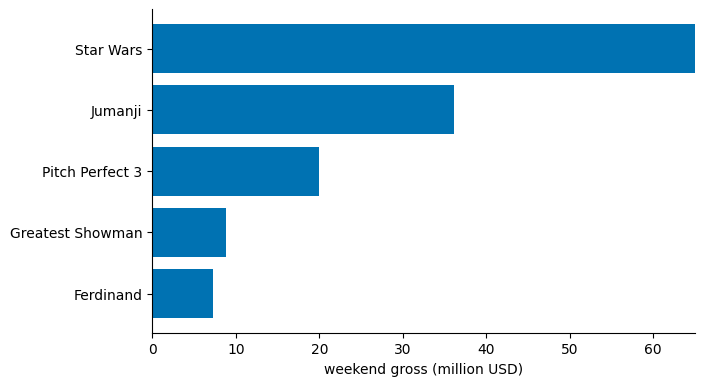

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(boxoffice["title"], boxoffice["amount"], color=BLUE)
ax.set_xlim(0, 65)
ax.set_xlabel("weekend gross (million USD)")
ax.set_ylabel("")
plt.show()

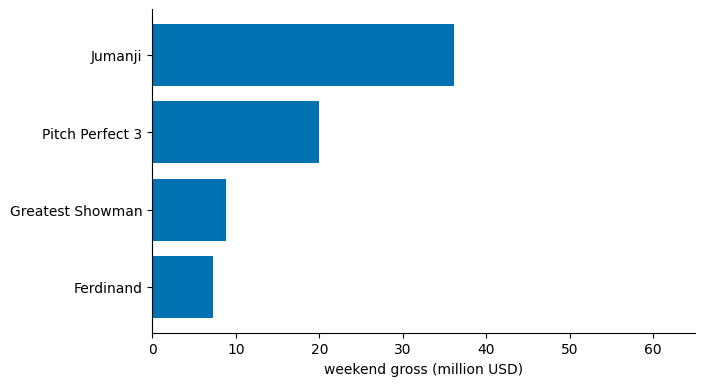

In [15]:
kept = boxoffice.loc[boxoffice["amount"] <= 65]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(kept["title"], kept["amount"], color=BLUE)
ax.set_xlim(0, 65)
ax.set_xlabel("weekend gross (million USD)")
ax.set_ylabel("")
plt.show()

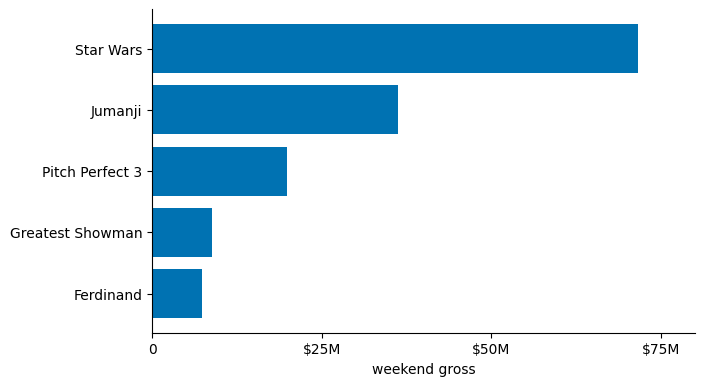

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(boxoffice["title"], boxoffice["amount"], color=BLUE)
ax.set_xlim(0, 80)
ax.set_xticks([0, 25, 50, 75])
ax.set_xticklabels(["0", "$25M", "$50M", "$75M"])
ax.set_xlabel("weekend gross")
ax.set_ylabel("")
plt.show()

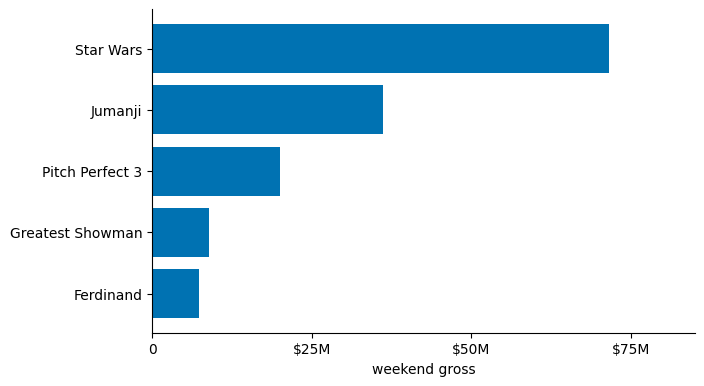

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(boxoffice["title"], boxoffice["amount"], color=BLUE)
ax.set_xlim(0, 85)
ax.set_xticks([0, 25, 50, 75])
ax.set_xticklabels(["0", "$25M", "$50M", "$75M"])
ax.set_xlabel("weekend gross")
ax.set_ylabel("")
plt.show()

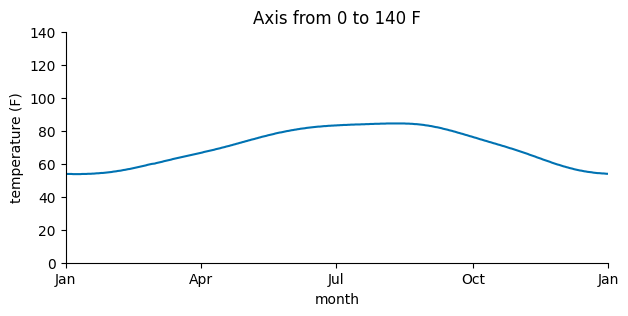

In [18]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(houston["day_of_year"], houston["temperature"], color=BLUE)
ax.set_ylim(0, 140)
ax.set_ylabel("temperature (F)")
ax.set_xlim(1, 366)
ax.set_xticks([1, 92, 183, 275, 366])
ax.set_xticklabels(["Jan", "Apr", "Jul", "Oct", "Jan"])
ax.set_xlabel("month")
ax.set_title("Axis from 0 to 140 F")
plt.show()

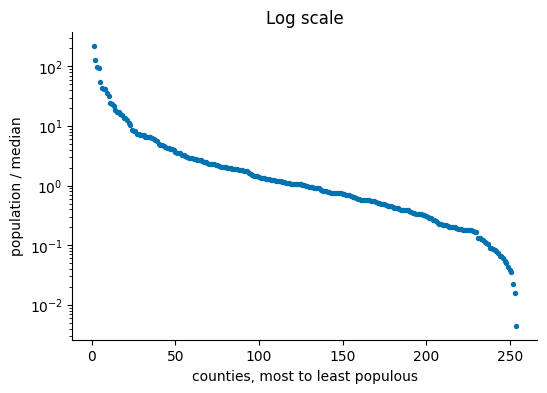

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(texas["index"], texas["popratio"], s=8, color=BLUE)
ax.set_yscale("log")
ax.set_xlabel("counties, most to least populous")
ax.set_ylabel("population / median")
ax.set_title("Log scale")
plt.show()

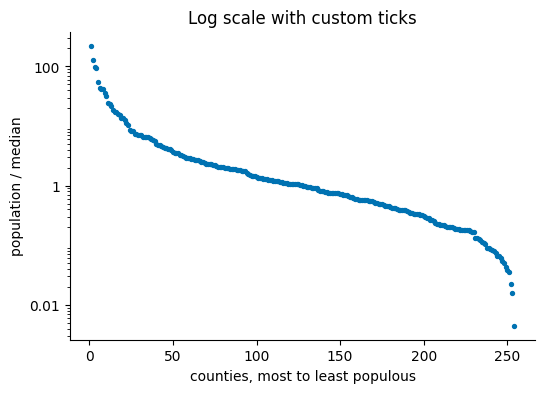

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(texas["index"], texas["popratio"], s=8, color=BLUE)
ax.set_yscale("log")
ax.set_yticks([0.01, 1, 100])
ax.set_yticklabels(["0.01", "1", "100"])
ax.set_xlabel("counties, most to least populous")
ax.set_ylabel("population / median")
ax.set_title("Log scale with custom ticks")
plt.show()

Harris / Dallas: 1.7281329347643868


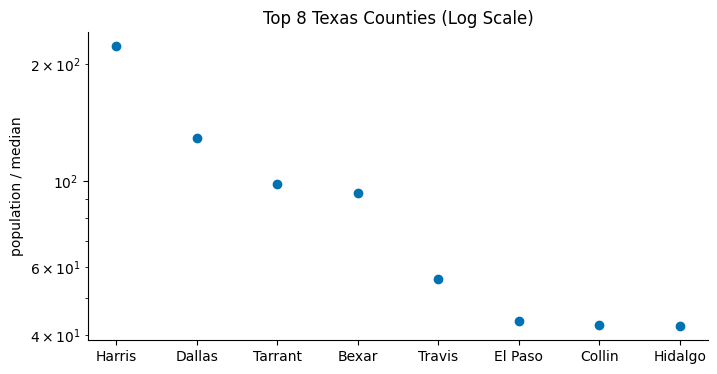

In [21]:
harris_pop = texas.loc[texas["county"] == "Harris", "pop2010"].iloc[0]
dallas_pop = texas.loc[texas["county"] == "Dallas", "pop2010"].iloc[0]
print("Harris / Dallas:", harris_pop / dallas_pop)

top8 = texas.head(8)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(top8["county"], top8["popratio"], color=BLUE)
ax.set_yscale("log")
ax.set_ylabel("population / median")
ax.set_title("Top 8 Texas Counties (Log Scale)")
plt.show()

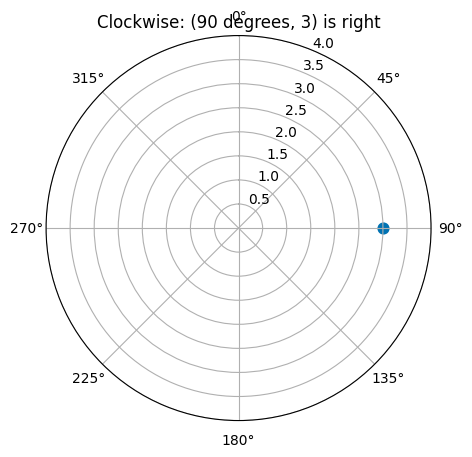

In [22]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="polar")

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.scatter([np.pi / 2], [3], s=60, color=BLUE)
ax.set_ylim(0, 4)
ax.set_title("Clockwise: (90 degrees, 3) is right")
plt.show()

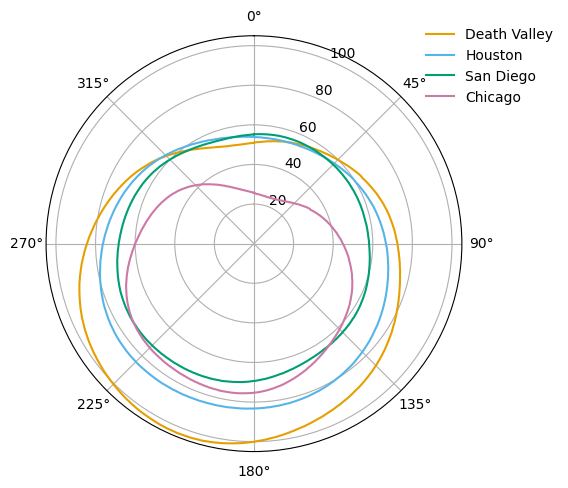

In [23]:
fig = plt.figure(figsize=(6.2, 5.4))
ax = fig.add_subplot(projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.plot(death_valley_angle, death_valley["temperature"], color="#E69F00", label="Death Valley")
ax.plot(houston_angle, houston["temperature"], color="#56B4E9", label="Houston")
ax.plot(san_diego_angle, san_diego["temperature"], color="#009E73", label="San Diego")
ax.plot(chicago_angle, chicago["temperature"], color="#CC79A7", label="Chicago")

ax.set_ylim(0, 105)

ax.legend(frameon=False, bbox_to_anchor=(1.25, 1.05))
plt.show()